<a href="https://colab.research.google.com/github/miku390219/ml-practice/blob/main/Data5_modelEvaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Evaluation and Refinement

**・モデル評価**

    R^2値、考査検証(Cross-Validation)

**・Over-fitting, Under-fitting**

**・Ridge回帰**

    通常の線形回帰に正則化工を加えて過学習を防ぐ

**・Grid Search**

    モデルのハイパーパラメータを自動で探索する

In [90]:
# ライブラリのインストール（Colabには多くが既にインストール済みだが念のため）
!pip install pandas matplotlib scipy scikit-learn seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ファイルのダウンロード
import urllib.request

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/module_5_auto.csv'
filename = 'module_5_auto.csv'

urllib.request.urlretrieve(url, filename)

('module_5_auto.csv', <http.client.HTTPMessage at 0x7cead3f8dd60>)

In [91]:
df = pd.read_csv("module_5_auto.csv", header=0)

In [92]:
df.head()

,Unnamed: 0.1,Unnamed: 0,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,0,0,3,122,alfa-romero,std,two,convertible,rwd,front,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,1,1,3,122,alfa-romero,std,two,convertible,rwd,front,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,2,2,1,122,alfa-romero,std,two,hatchback,rwd,front,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,3,3,2,164,audi,std,four,sedan,fwd,front,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,4,4,2,164,audi,std,four,sedan,4wd,front,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


In [93]:
#only use numeric data
df=df._get_numeric_data()
df.head()

,Unnamed: 0.1,Unnamed: 0,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,...,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
0,0,0,3,122,88.6,0.811148,0.890278,48.8,2548,130,...,2.68,9.0,111.0,5000.0,21,27,13495.0,11.190476,0,1
1,1,1,3,122,88.6,0.811148,0.890278,48.8,2548,130,...,2.68,9.0,111.0,5000.0,21,27,16500.0,11.190476,0,1
2,2,2,1,122,94.5,0.822681,0.909722,52.4,2823,152,...,3.47,9.0,154.0,5000.0,19,26,16500.0,12.368421,0,1
3,3,3,2,164,99.8,0.848630,0.919444,54.3,2337,109,...,3.40,10.0,102.0,5500.0,24,30,13950.0,9.791667,0,1
4,4,4,2,164,99.4,0.848630,0.922222,54.3,2824,136,...,3.40,8.0,115.0,5500.0,18,22,17450.0,13.055556,0,1


In [94]:
df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1, inplace=True)
df.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
0,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,11.190476,0,1
1,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,11.190476,0,1
2,1,122,94.5,0.822681,0.909722,52.4,2823,152,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,12.368421,0,1
3,2,164,99.8,0.848630,0.919444,54.3,2337,109,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0,9.791667,0,1
4,2,164,99.4,0.848630,0.922222,54.3,2824,136,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0,13.055556,0,1


In [95]:
import ipywidgets
from ipywidgets import interact, interactive, fixed, interact_manual

In [96]:
def DistributionPlot(RedFunction, BlueFunction, RedName, BlueName, Title):
    width = 12
    height = 10
    plt.figure(figsize=(width, height))

    ax1 = sns.kdeplot(RedFunction, color="r", label=RedName)
    ax2 = sns.kdeplot(BlueFunction, color="b", label=BlueName, ax=ax1)

    plt.title(Title)
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')
    plt.show()
    plt.close()

In [97]:
def PollyPlot(xtrain, xtest, y_train, y_test, lr,poly_transform):
    width = 12
    height = 10
    plt.figure(figsize=(width, height))


    #training data
    #testing data
    # lr:  linear regression object
    #poly_transform:  polynomial transformation object

    xmax=max([xtrain.values.max(), xtest.values.max()])

    xmin=min([xtrain.values.min(), xtest.values.min()])

    x=np.arange(xmin, xmax, 0.1)


    plt.plot(xtrain, y_train, 'ro', label='Training Data')
    plt.plot(xtest, y_test, 'go', label='Test Data')
    plt.plot(x, lr.predict(poly_transform.fit_transform(x.reshape(-1, 1))), label='Predicted Function')
    plt.ylim([-10000, 60000])
    plt.ylabel('Price')
    plt.legend()

# Training and Testing

In [98]:
y_data = df['price']
x_data = df.drop(['price'], axis=1)

In [99]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.10, random_state=1)

print("number of test samples: ", x_test.shape[0])
print("number of training samples: ", x_train.shape[0])

number of test samples:  21
number of training samples:  180


In [100]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x_data, y_data, test_size=0.4, random_state = 0)

In [101]:
from sklearn.linear_model import LinearRegression
lre=LinearRegression()

lre.fit(x_train[['horsepower']], y_train)

LinearRegression()

In [102]:
lre.score(x_test[['horsepower']], y_test)

0.36358755750788263

In [103]:
lre.score(x_train[['horsepower']], y_train)

0.6619724197515104

In [104]:
lre.fit(x_train1[['horsepower']],y_train1)

LinearRegression()

In [105]:
lre.score(x_test1[['horsepower']], y_test1)

0.7139364665406973

In [106]:
lre.score(x_train1[['horsepower']], y_train1)

0.5754067463583004

十分な数のデータがないとき：Cross-Validation

In [107]:
from sklearn.model_selection import cross_val_score

In [108]:
#cv : データの分割数
Rcross = cross_val_score(lre, x_data[['horsepower']], y_data, cv=4)

In [109]:
Rcross

array([0.7746232 , 0.51716687, 0.74785353, 0.04839605])

In [110]:
print("The mean of the folds are", Rcross.mean(),"and the standard deviation is", Rcross.std())

The mean of the folds are 0.522009915042119 and the standard deviation is 0.291183944475603


 A negative R^2 is a sign of overfitting.

In [111]:
-1 * cross_val_score(lre, x_data[['horsepower']], y_data, cv=4, scoring='neg_mean_squared_error')

array([20254142.84026702, 43745493.2650517 , 12539630.34014931,
       17561927.72247591])

In [112]:
RC=cross_val_score(lre, x_data[['horsepower']], y_data, cv=2)

In [113]:
RC

array([0.59015621, 0.44319613])

In [114]:
RC.mean()

np.float64(0.5166761697127429)

In [115]:
from sklearn.model_selection import cross_val_predict

In [116]:
yhat = cross_val_predict(lre, x_data[['horsepower']], y_data, cv=4)
yhat[0:5]

array([14141.63807508, 14141.63807508, 20814.29423473, 12745.03562306,
       14762.35027598])

# Overfitting, Underfitting and Model Selection

In [117]:
lr = LinearRegression()

In [118]:
#x_train : 自動車の価格（y_train）を予測するために選ばれた特徴量
lr.fit(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_train)

LinearRegression()

In [119]:
yhat_train = lr.predict(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
yhat_train[0:5]
#lr.predict(...) → 訓練データ全件の予測価格を計算し、yhat_train に格納
#yhat_train[0:5] → そのうちインデックス0〜4の5件だけを取り出して確認

array([ 7426.6731551 , 28323.75090803, 14213.38819709,  4052.34146983,
       34500.19124244])

In [120]:
yhat_test = lr.predict(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
yhat_test[0:5]

array([11349.35089149,  5884.11059106, 11208.6928275 ,  6641.07786278,
       15565.79920282])

In [121]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

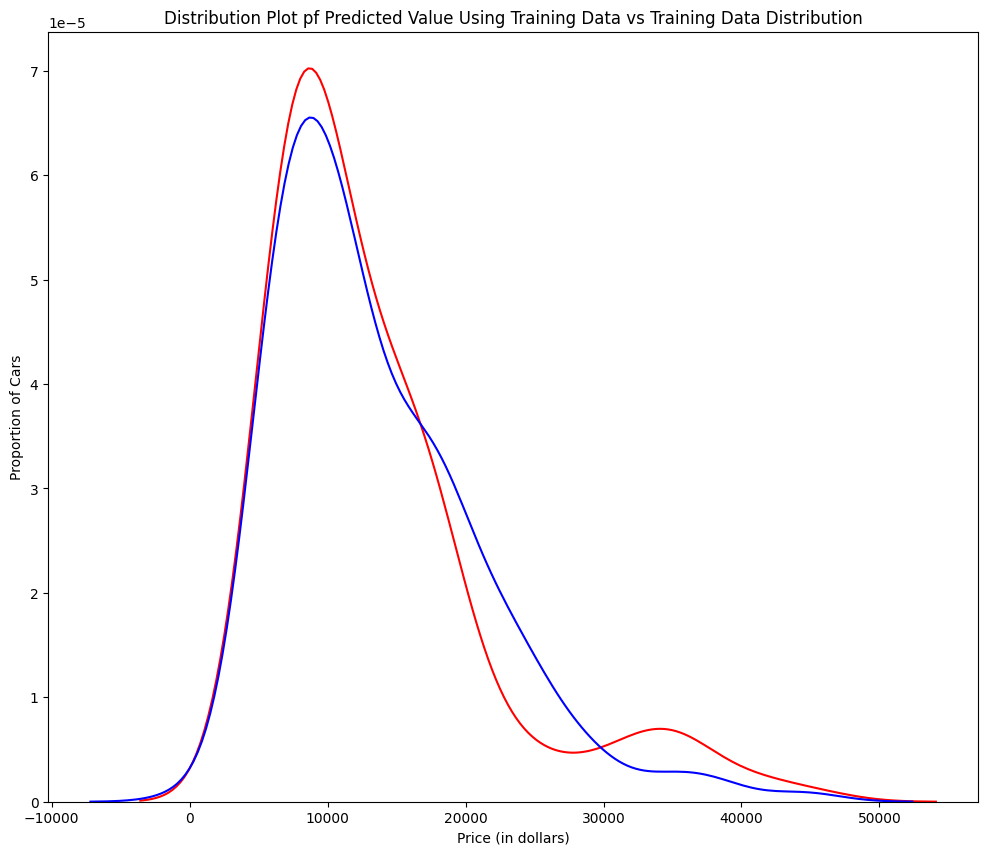

In [122]:
Title = 'Distribution Plot pf Predicted Value Using Training Data vs Training Data Distribution'
DistributionPlot(y_train, yhat_train, "Actual Values (train)", "Predicted Values (Train)", Title)

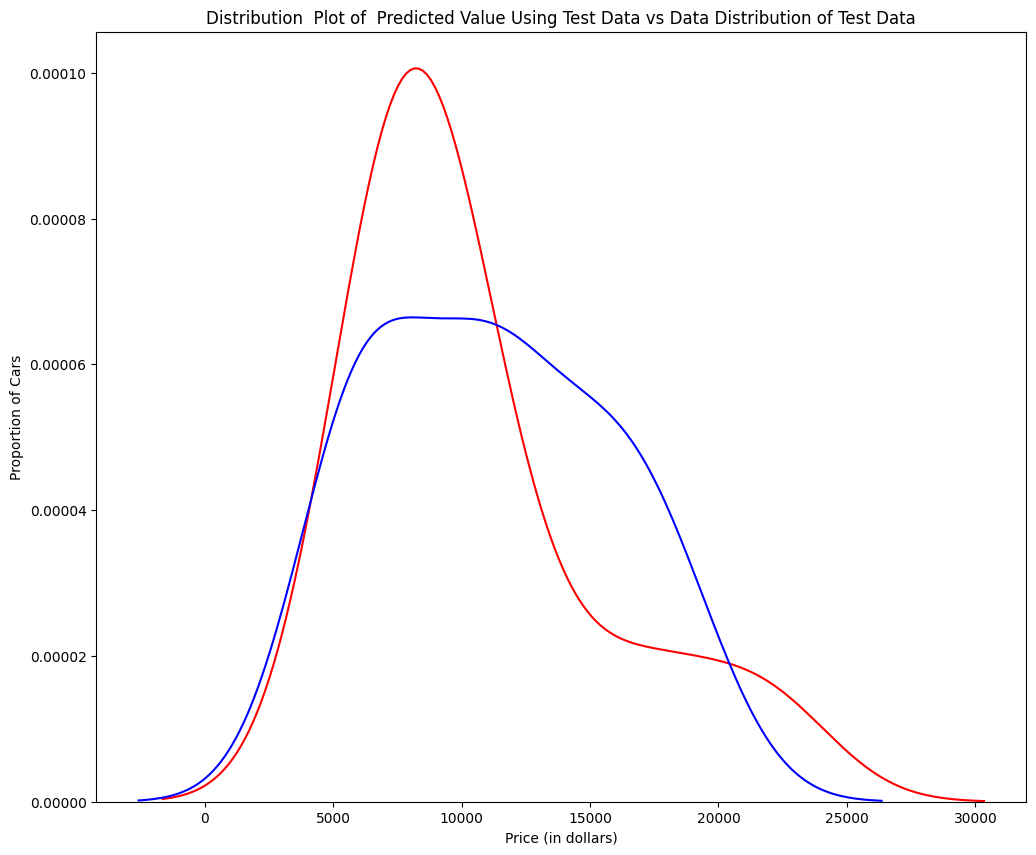

In [123]:
Title='Distribution  Plot of  Predicted Value Using Test Data vs Data Distribution of Test Data'
DistributionPlot(y_test,yhat_test,"Actual Values (Test)","Predicted Values (Test)",Title)

In [124]:
from sklearn.preprocessing import PolynomialFeatures

In [125]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size = 0.45, random_state = 0)

In [126]:
pr = PolynomialFeatures(degree=5)
x_train_pr = pr.fit_transform(x_train[['horsepower']])
x_test_pr = pr.fit_transform(x_test[['horsepower']])
pr

PolynomialFeatures(degree=5)

In [127]:
poly = LinearRegression()
poly.fit(x_train_pr, y_train)

LinearRegression()

In [128]:
yhat = poly.predict(x_test_pr)
yhat[0:5]

array([ 6728.65561887,  7307.98782321, 12213.78770965, 18893.24804015,
       19995.95195136])

In [129]:
print("Predicted Values : ", yhat[0:4])
print("True Values : ", y_test[0:4].values)

Predicted Values :  [ 6728.65561887  7307.98782321 12213.78770965 18893.24804015]
True Values :  [ 6295. 10698. 13860. 13499.]


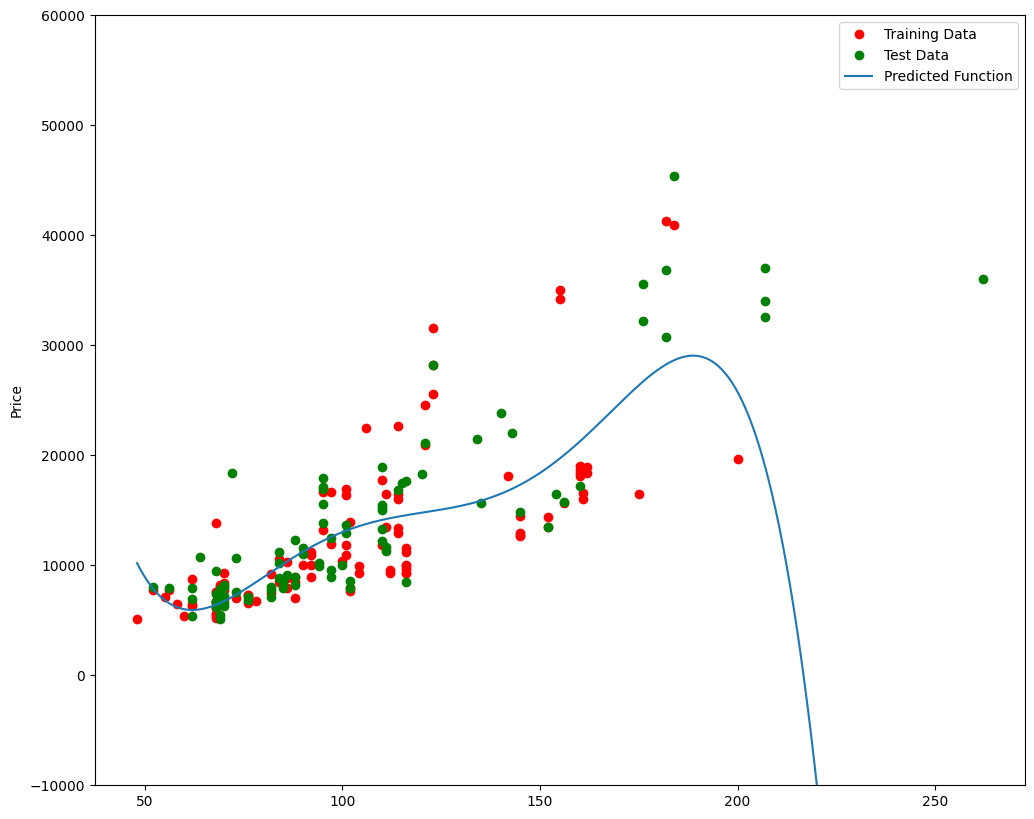

In [130]:
PollyPlot(x_train['horsepower'], x_test['horsepower'], y_train, y_test, poly, pr)

In [131]:
poly.score(x_train_pr, y_train)

0.5567716902120254

Text(3, 0.75, 'Maximum R^2')

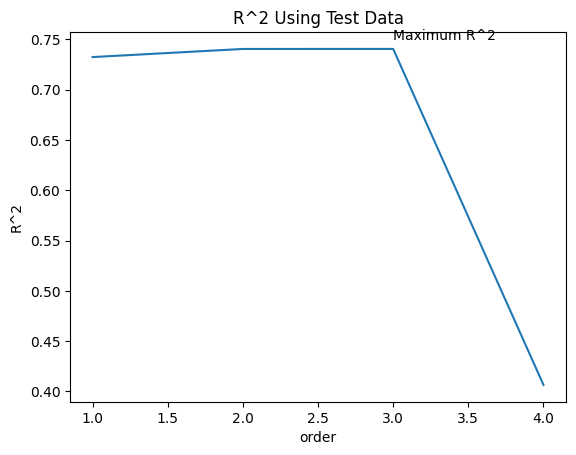

In [132]:
Rsqu_test = []

#次数を1次から4次まで変化させてR^2値を比較
order = [1, 2, 3, 4]
for n in order:
  pr = PolynomialFeatures(degree=n)

  x_train_pr = pr.fit_transform(x_train[['horsepower']])
  x_test_pr = pr.fit_transform(x_test[['horsepower']])
  lr.fit(x_train_pr, y_train)

  Rsqu_test.append(lr.score(x_test_pr, y_test))

plt.plot(order, Rsqu_test)
plt.xlabel('order')
plt.ylabel('R^2')
plt.title('R^2 Using Test Data')
plt.text(3, 0.75, 'Maximum R^2')

In [133]:
#order = 3でR^2値が最大となるため、3次の多項式で回帰を行うのが最適

In [134]:
def f(order, test_data):
  x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size = test_data, random_state = 0)
  pr = PolynomialFeatures(degree=order)
  x_train_pr = pr.fit_transform(x_train[['horsepower']])
  x_test_pr = pr.fit_transform(x_test[['horsepower']])
  poly = LinearRegression()
  poly.fit(x_train_pr, y_train)
  PollyPlot(x_train['horsepower'], x_test['horsepower'], y_train, y_test, poly, pr)

In [135]:
#order = (0, 6, 1):多項式の次数を1刻みで0～6で選択
#test_data=(0.05, 0.95, 0.05):テストデータの割合を、5%～95%を5%刻みで選択
interact(f, order=(0, 6, 1), test_data=(0.05, 0.95, 0.05))

interactive(children=(IntSlider(value=3, description='order', max=6), FloatSlider(value=0.45, description='tes…

<function __main__.f(order, test_data)>

In [136]:
pr1 = PolynomialFeatures(degree=2)

In [137]:
x_train_pr1 = pr1.fit_transform(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
x_test_pr1 = pr1.fit_transform(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])

In [138]:
x_train_pr1.shape

(110, 15)

In [139]:
poly1=LinearRegression().fit(x_train_pr1, y_train)

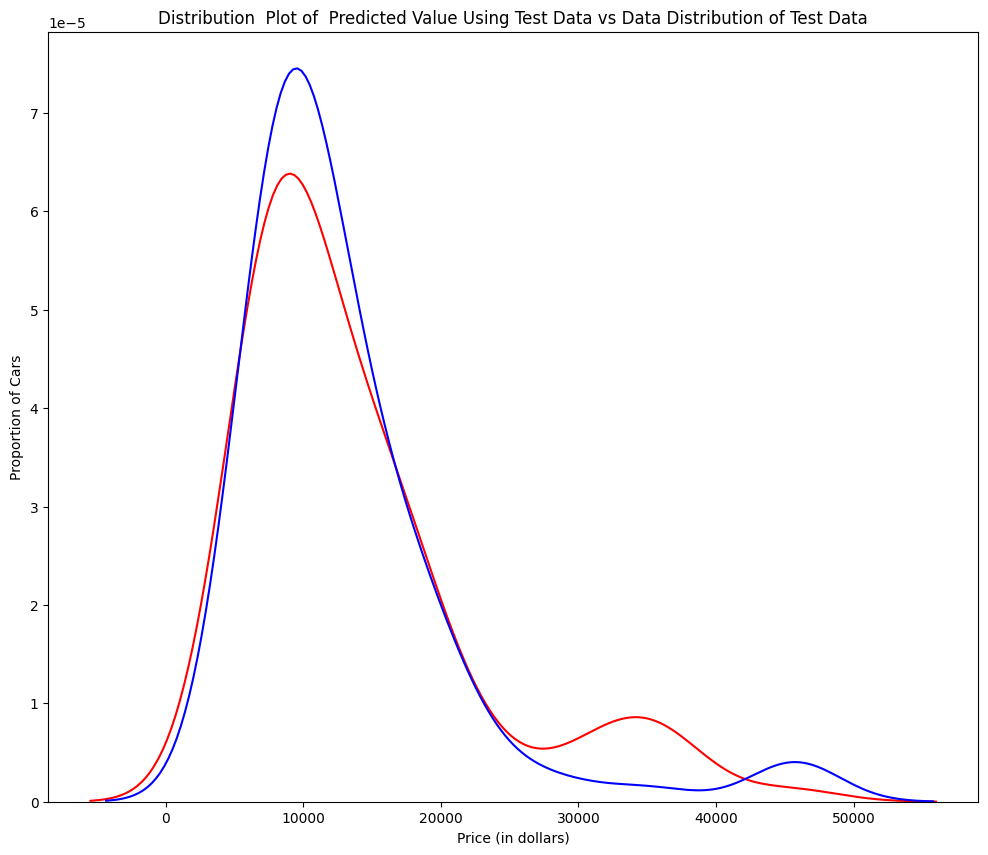

In [140]:
yhat_test1=poly1.predict(x_test_pr1)

Title='Distribution  Plot of  Predicted Value Using Test Data vs Data Distribution of Test Data'

DistributionPlot(y_test, yhat_test1, "Actual Values (Test)", "Predicted Values (Test)", Title)

In [141]:
#The predicted value is higher than actual value for cars where the price
# $10,000 range, conversely the predicted price is lower than the price
# cost in the $30,000 to $40,000 range. As such the model is not as
#accurate in these ranges.

# Ridge回帰

In [142]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg','normalized-losses','symboling']])
x_test_pr = pr.fit_transform(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg','normalized-losses','symboling']])


In [143]:
from sklearn.linear_model import Ridge

In [144]:
RidgeModel = Ridge(alpha = 1)

In [145]:
RidgeModel.fit(x_train_pr, y_train)

Ridge(alpha=1)

In [146]:
yhat = RidgeModel.predict(x_test_pr)

In [147]:
print('Predicted : ', yhat[0:4])
print('test set : ', y_test[0:4].values)

Predicted :  [ 6570.82441941  9636.24891471 20949.92322737 19403.60313256]
test set :  [ 6295. 10698. 13860. 13499.]


In [148]:
from tqdm import tqdm

Rsqu_test = []
Rsqu_train = []
dummy1 = []
Alpha = 10 * np.array(range(0,1000))
pbar = tqdm(Alpha)

for alpha in pbar:
    RigeModel = Ridge(alpha=alpha)
    RigeModel.fit(x_train_pr, y_train)
    test_score, train_score = RigeModel.score(x_test_pr, y_test), RigeModel.score(x_train_pr, y_train)

    pbar.set_postfix({"Test Score": test_score, "Train Score": train_score})

    Rsqu_test.append(test_score)
    Rsqu_train.append(train_score)

100%|██████████| 1000/1000 [00:11<00:00, 85.03it/s, Test Score=0.564, Train Score=0.859]


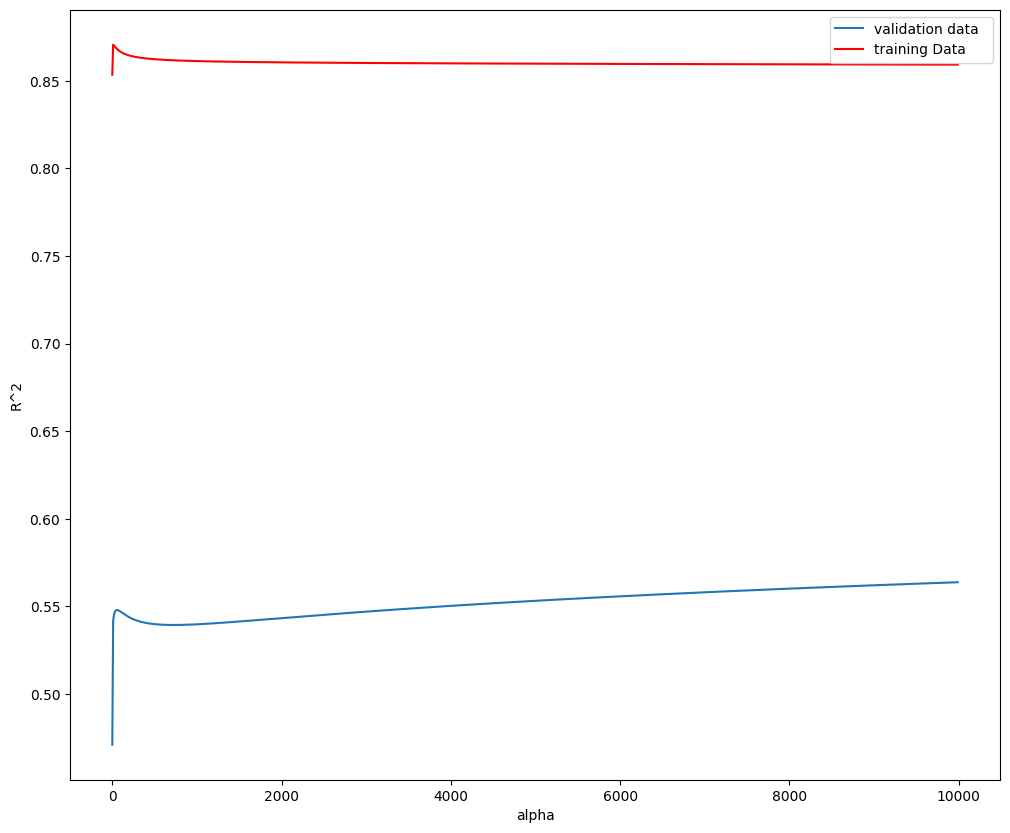

In [149]:
width = 12
height = 10
plt.figure(figsize=(width, height))

plt.plot(Alpha,Rsqu_test, label='validation data  ')
plt.plot(Alpha,Rsqu_train, 'r', label='training Data ')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.legend()

In [150]:
RigeModel = Ridge(alpha=10)
RigeModel.fit(x_train_pr, y_train)
RigeModel.score(x_test_pr, y_test)

0.5418576440206506

# Grid Search

In [151]:
from sklearn.model_selection import GridSearchCV

In [152]:
parameters1= [{'alpha': [0.001,0.1,1, 10, 100, 1000, 10000, 100000, 100000]}]
parameters1

[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000, 100000]}]

In [153]:
RR=Ridge()
RR

Ridge()

In [154]:
Grid1 = GridSearchCV(RR, parameters1,cv=4)

In [155]:
Grid1.fit(x_data[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_data)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000,
                                    100000]}])

In [156]:
BestRR=Grid1.best_estimator_
BestRR

Ridge(alpha=10000)

In [157]:
BestRR.score(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_test)

0.8411649831036151

In [158]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_data[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])

# Define parameter grid without 'normalize'
parameters2 = [{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]}]

# Perform Grid Search
Grid2 = GridSearchCV(Ridge(), parameters2, cv=4)
Grid2.fit(x_scaled, y_data)

# Best model
best_ridge_model = Grid2.best_estimator_
best_alpha = Grid2.best_params_['alpha']
best_alpha

100